# Desafío 2 — Situación 3

## Clustering no supervisado de imágenes satelitales EuroSAT

Este notebook desarrolla la Situación 3 del desafío, siguiendo estrictamente el flujo solicitado: preparación de imágenes, reducción dimensional, modelado de clustering con K-Means y preparación para validación posterior.

La idea central es trabajar las imágenes como datos multivariados: cada imagen se convierte en un vector numérico, luego se reduce la dimensionalidad mediante PCA y finalmente se aplican modelos de clustering sobre el espacio reducido.

## 1. Librerías y configuración general

Se importan las librerías necesarias para manipulación de datos, carga de imágenes, reducción dimensional, clustering y visualización.

In [2]:
from pathlib import Path

import numpy as np
pandas_instalado = True
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 2. Carga del dataset y construcción del índice de imágenes

El dataset EuroSAT se encuentra organizado en carpetas, donde cada carpeta corresponde a una clase real de cobertura terrestre. Estas etiquetas se usarán solamente al final para validación externa, no durante el ajuste de los modelos de clustering.

Ajusta la variable `ruta_dataset` según la ubicación local del dataset en tu computador.

In [3]:
# Cambia esta ruta por la ubicación real de tu dataset
ruta_dataset = Path("EuroSAT_RGB")


def construir_indice_imagenes(ruta_dataset, extensiones=("*.jpg", "*.jpeg", "*.png")):
    """
    Construye un DataFrame con la ruta de cada imagen y su clase real,
    tomada del nombre de la carpeta contenedora.
    """
    registros = []

    for carpeta_clase in sorted(ruta_dataset.iterdir()):
        if carpeta_clase.is_dir():
            for extension in extensiones:
                for imagen in carpeta_clase.glob(extension):
                    registros.append({
                        "ruta": str(imagen),
                        "clase_real": carpeta_clase.name
                    })

    return pd.DataFrame(registros)


df_imagenes = construir_indice_imagenes(ruta_dataset)

print("Total de imágenes:", len(df_imagenes))
print("Número de clases:", df_imagenes["clase_real"].nunique())
display(df_imagenes["clase_real"].value_counts())
display(df_imagenes.head())

Total de imágenes: 27000
Número de clases: 10


clase_real
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

,ruta,clase_real
0,EuroSAT_RGB/AnnualCrop/AnnualCrop_157.jpg,AnnualCrop
1,EuroSAT_RGB/AnnualCrop/AnnualCrop_1948.jpg,AnnualCrop
2,EuroSAT_RGB/AnnualCrop/AnnualCrop_2607.jpg,AnnualCrop
3,EuroSAT_RGB/AnnualCrop/AnnualCrop_1905.jpg,AnnualCrop
4,EuroSAT_RGB/AnnualCrop/AnnualCrop_804.jpg,AnnualCrop


## 3. Preparación mínima de datos para clustering

Para aplicar PCA y clustering, cada imagen RGB se transforma en un vector numérico. Si las imágenes tienen tamaño 64×64 y tres canales, cada observación queda representada por 12.288 variables.

Este paso no introduce modelos adicionales: solo convierte las imágenes a una matriz numérica `X` apta para análisis multivariado.

In [4]:
def cargar_imagenes_como_matriz(df_imagenes, tamano=(64, 64)):
    """
    Convierte las imágenes en una matriz numérica.
    Cada imagen se redimensiona, se normaliza a [0, 1] y se vectoriza.
    """
    X = []

    for ruta in tqdm(df_imagenes["ruta"], desc="Procesando imágenes"):
        imagen = Image.open(ruta).convert("RGB")
        imagen = imagen.resize(tamano)
        arreglo = np.array(imagen, dtype=np.float32) / 255.0
        X.append(arreglo.flatten())

    return np.array(X)


X = cargar_imagenes_como_matriz(df_imagenes)

print("Forma de la matriz X:", X.shape)

Procesando imágenes: 100%|██████████| 27000/27000 [00:05<00:00, 4522.30it/s]


Forma de la matriz X: (27000, 12288)


## 4. Escalamiento y PCA inicial

Como la matriz original tiene alta dimensionalidad, se aplica PCA para construir un espacio reducido. El clustering se realizará sobre este espacio reducido, tal como solicita la situación.

In [5]:
def escalar_datos(X):
    """
    Estandariza la matriz de datos.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


def ajustar_pca_inicial(X_scaled):
    """
    Ajusta PCA completo para analizar la varianza explicada acumulada.
    """
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca


X_scaled, scaler = escalar_datos(X)
X_pca, pca_inicial = ajustar_pca_inicial(X_scaled)

print("Forma de X_scaled:", X_scaled.shape)
print("Forma de X_pca:", X_pca.shape)

Forma de X_scaled: (27000, 12288)
Forma de X_pca: (27000, 12288)


## 5. Selección del número de componentes principales

Se analiza la varianza explicada acumulada para decidir cuántos componentes principales conservar. Esta decisión define la dimensión final `m` del espacio reducido.

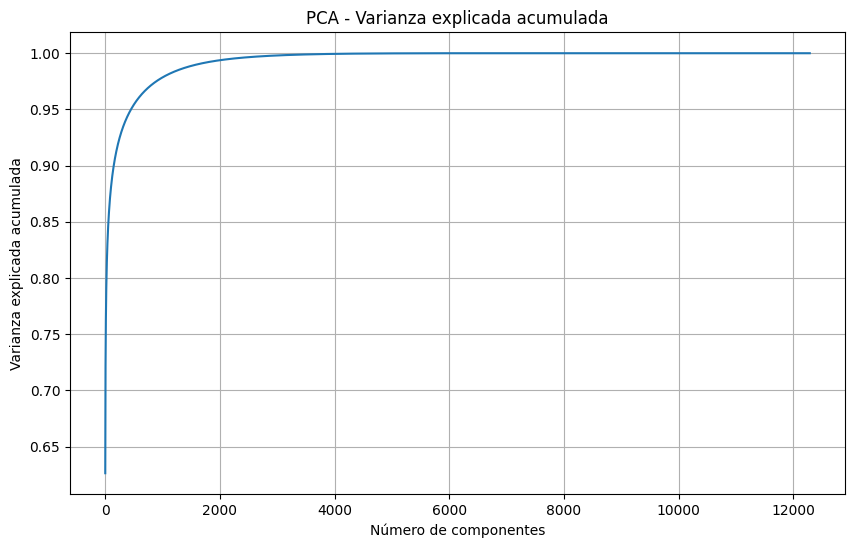

,umbral_varianza,porcentaje_varianza,componentes_necesarios,varianza_acumulada
0,0.80,80%,23,0.801680
1,0.85,85%,56,0.850159
2,0.90,90%,149,0.900021
3,0.95,95%,451,0.950072


In [6]:
def graficar_varianza_acumulada(pca):
    """
    Grafica la varianza explicada acumulada del PCA.
    """
    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza explicada acumulada")
    plt.title("PCA - Varianza explicada acumulada")
    plt.grid(True)
    plt.show()

    return varianza_acumulada


def calcular_componentes_por_varianza(pca, umbrales=(0.80, 0.85, 0.90, 0.95)):
    """
    Calcula cuántos componentes principales se necesitan para alcanzar
    distintos umbrales de varianza explicada acumulada.
    """
    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
    resultados = []

    for umbral in umbrales:
        m = np.argmax(varianza_acumulada >= umbral) + 1
        resultados.append({
            "umbral_varianza": umbral,
            "porcentaje_varianza": f"{umbral * 100:.0f}%",
            "componentes_necesarios": m,
            "varianza_acumulada": varianza_acumulada[m - 1]
        })

    return pd.DataFrame(resultados)


varianza_acumulada = graficar_varianza_acumulada(pca_inicial)
tabla_componentes = calcular_componentes_por_varianza(pca_inicial)

display(tabla_componentes)

## 6. Construcción del espacio reducido final

Con base en la tabla anterior, se selecciona un número de componentes `m`. En la ejecución previa se observó que 149 componentes conservan aproximadamente el 90% de la varianza, pero este valor puede ajustarse si tus resultados cambian.

In [7]:
def aplicar_pca_con_m_componentes(X_scaled, m):
    """
    Aplica PCA con m componentes y devuelve el espacio reducido.
    """
    pca = PCA(n_components=m)
    X_reducido = pca.fit_transform(X_scaled)
    return X_reducido, pca


# Ajusta m si tu tabla de varianza explicada sugiere otro valor
m = 149

X_reducido, pca_final = aplicar_pca_con_m_componentes(X_scaled, m)

print("Forma del espacio reducido:", X_reducido.shape)
print("Varianza acumulada retenida:", pca_final.explained_variance_ratio_.sum())

Forma del espacio reducido: (27000, 149)
Varianza acumulada retenida: 0.899887


## 7. Modelado de clustering con K-Means

Se evalúa K-Means para distintos valores de `k`. El enunciado solicita usar el método del codo mediante SSE/inercia y, de manera más importante, el coeficiente de silueta.

In [8]:
def evaluar_kmeans(X, rango_k=range(2, 13), random_state=42, muestra_silueta=5000):
    """
    Evalúa K-Means para varios valores de k usando inercia y silueta.
    La silueta se calcula sobre una muestra para reducir costo computacional.
    """
    resultados = []

    for k in tqdm(rango_k, desc="Evaluando K-Means"):
        modelo = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X)

        silueta = silhouette_score(
            X,
            etiquetas,
            sample_size=muestra_silueta,
            random_state=random_state
        )

        resultados.append({
            "k": k,
            "inercia_sse": modelo.inertia_,
            "silueta": silueta
        })

    return pd.DataFrame(resultados)


tabla_kmeans = evaluar_kmeans(
    X_reducido,
    rango_k=range(2, 13),
    random_state=42,
    muestra_silueta=5000
)

display(tabla_kmeans)

Evaluando K-Means: 100%|██████████| 11/11 [00:10<00:00,  1.10it/s]


,k,inercia_sse,silueta
0,2,161507456.0,0.404421
1,3,125496080.0,0.314879
2,4,111205504.0,0.244327
3,5,103860304.0,0.209614
4,6,99672968.0,0.171036
5,7,97141888.0,0.150504
6,8,95147288.0,0.147268
7,9,93429112.0,0.147722
8,10,92099328.0,0.115717
9,11,91042360.0,0.099441


## 8. Gráficos para selección de k

El método del codo muestra cómo disminuye la inercia al aumentar el número de clústeres. El coeficiente de silueta permite evaluar separación y cohesión de los grupos.

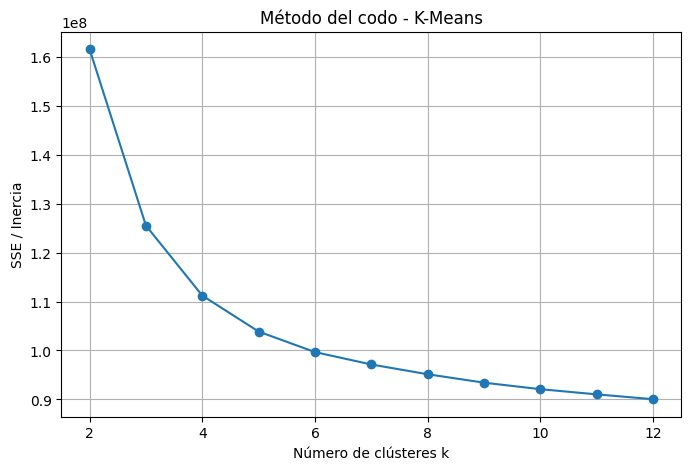

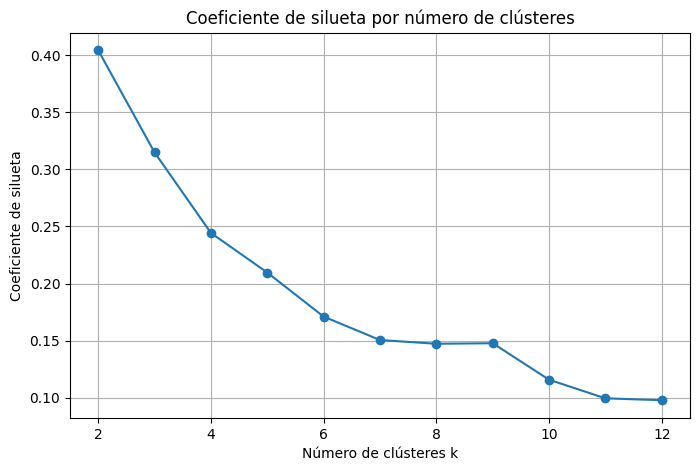

Mejor k según silueta: 2
Silueta máxima: 0.4044208526611328


In [9]:
def graficar_codo(tabla_kmeans):
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["inercia_sse"], marker="o")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("SSE / Inercia")
    plt.title("Método del codo - K-Means")
    plt.grid(True)
    plt.show()


def graficar_silueta(tabla_kmeans):
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["silueta"], marker="o")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("Coeficiente de silueta")
    plt.title("Coeficiente de silueta por número de clústeres")
    plt.grid(True)
    plt.show()


graficar_codo(tabla_kmeans)
graficar_silueta(tabla_kmeans)

mejor_fila = tabla_kmeans.loc[tabla_kmeans["silueta"].idxmax()]
k_optimo_silueta = int(mejor_fila["k"])

print("Mejor k según silueta:", k_optimo_silueta)
print("Silueta máxima:", mejor_fila["silueta"])

## 9. Ajuste final de K-Means

Siguiendo estrictamente la rúbrica, el modelo final de K-Means se ajusta con el valor de `k` que maximiza el coeficiente de silueta dentro del rango evaluado.

Si el análisis agroecológico requiriera una segmentación más granular, podría discutirse una solución alternativa, sin embargo, para esta entrega se prioriza el criterio cuantitativo solicitado.


In [10]:
def ajustar_kmeans_final(X, k, random_state=42):
    """
    Ajusta el modelo final de K-Means.
    """
    modelo = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    clusters = modelo.fit_predict(X)
    return clusters, modelo


k_final = k_optimo_silueta

clusters_kmeans, modelo_kmeans_final = ajustar_kmeans_final(X_reducido, k_final)

df_imagenes["cluster_kmeans"] = clusters_kmeans

print("k final seleccionado según silueta:", k_final)
display(df_imagenes["cluster_kmeans"].value_counts().sort_index())


k final seleccionado según silueta: 2


cluster_kmeans
0    10685
1    16315
Name: count, dtype: int64

## 10. Cruce preliminar con etiquetas reales

Aunque las etiquetas reales no se usan para entrenar el clustering, se pueden cruzar con los clústeres obtenidos para interpretar qué tipo de cobertura terrestre predomina en cada grupo. Esta parte será clave para el perfilado y la validación externa posterior.

In [11]:
tabla_cruce_kmeans_conteo = pd.crosstab(
    df_imagenes["cluster_kmeans"],
    df_imagenes["clase_real"]
)

tabla_cruce_kmeans_porcentaje = pd.crosstab(
    df_imagenes["cluster_kmeans"],
    df_imagenes["clase_real"],
    normalize="index"
) * 100

print("Conteos por cluster y clase real:")
display(tabla_cruce_kmeans_conteo)

print("Porcentajes por cluster y clase real:")
display(tabla_cruce_kmeans_porcentaje.round(2))

Conteos por cluster y clase real:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,2237,0,1127,779,2350,325,1701,1356,309,501
1,763,3000,1873,1721,150,1675,799,1644,2191,2499


Porcentajes por cluster y clase real:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,20.94,0.00,10.55,7.29,21.99,3.04,15.92,12.69,2.89,4.69
1,4.68,18.39,11.48,10.55,0.92,10.27,4.90,10.08,13.43,15.32


## 11. Modelado de clustering con DBSCAN

DBSCAN es un método basado en densidad. A diferencia de K-Means, no exige fijar previamente el número de clústeres y puede identificar observaciones como ruido (`cluster = -1`). Esto es útil en imágenes satelitales porque algunas escenas pueden ser mixtas o atípicas.

Como DBSCAN depende directamente de distancias, se estandariza el espacio PCA antes de aplicarlo. La estimación se realiza sobre `X_reducido`, no sobre los pixeles originales, para mantener la coherencia con la reducción dimensional solicitada.


In [12]:
def preparar_espacio_dbscan(X_reducido):
    """
    Estandariza el espacio PCA para DBSCAN.
    DBSCAN es sensible a escala porque usa distancias absolutas.
    """
    scaler = StandardScaler()
    X_dbscan = scaler.fit_transform(X_reducido)
    return X_dbscan, scaler


X_dbscan, scaler_dbscan = preparar_espacio_dbscan(X_reducido)

print("Forma de X_dbscan:", X_dbscan.shape)
print("Media aproximada:", np.round(X_dbscan.mean(), 4))
print("Desviación aproximada:", np.round(X_dbscan.std(), 4))


Forma de X_dbscan: (27000, 149)
Media aproximada: 0.0
Desviación aproximada: 1.0


## 12. Selección preliminar de `eps` mediante k-distance

El parámetro más sensible de DBSCAN es `eps`, que define el radio de vecindad. Para justificarlo se usa el gráfico de k-distancias: cada observación se ordena según la distancia a su vecino número `min_samples`.

Para mantener el análisis compacto, se toman tres candidatos de `eps` a partir de cuantiles altos de las k-distancias. Estos valores permiten contrastar soluciones más restrictivas o más permisivas sin convertir la sección en una búsqueda extensa de hiperparámetros.


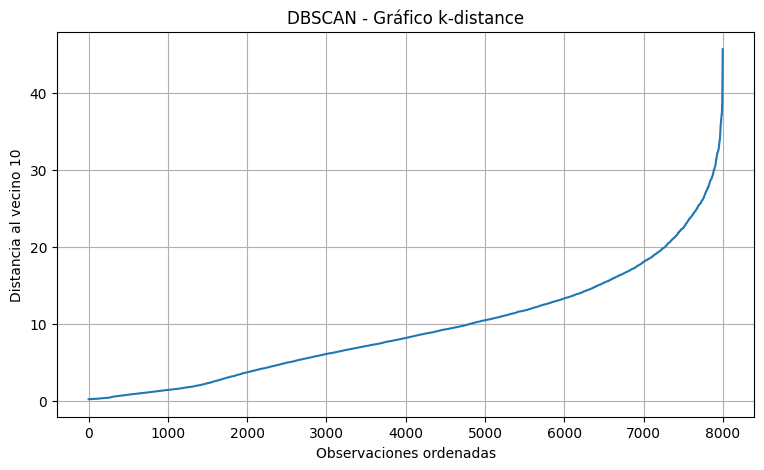

,cuantil,eps_candidato
0,0.85,16.790
1,0.90,19.415
2,0.95,23.886


In [13]:
def calcular_k_distancias(X, min_samples=10, muestra=8000, random_state=42):
    """
    Calcula las distancias al k-ésimo vecino más cercano.
    Si el dataset es grande, usa una muestra para reducir costo computacional.
    """
    rng = np.random.default_rng(random_state)

    if muestra is not None and X.shape[0] > muestra:
        indices = rng.choice(X.shape[0], size=muestra, replace=False)
        X_eval = X[indices]
    else:
        X_eval = X

    vecinos = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
        n_jobs=-1
    )
    vecinos.fit(X_eval)

    distancias, _ = vecinos.kneighbors(X_eval)
    k_distancias = np.sort(distancias[:, -1])

    return k_distancias


def graficar_k_distancias(k_distancias, min_samples):
    """
    Grafica las k-distancias ordenadas para apoyar la selección de eps.
    """
    plt.figure(figsize=(9, 5))
    plt.plot(k_distancias)
    plt.xlabel("Observaciones ordenadas")
    plt.ylabel(f"Distancia al vecino {min_samples}")
    plt.title("DBSCAN - Gráfico k-distance")
    plt.grid(True)
    plt.show()


def proponer_eps_por_cuantiles(k_distancias, cuantiles=(0.85, 0.90, 0.95)):
    """
    Propone valores de eps a partir de cuantiles de las k-distancias.
    """
    valores = np.quantile(k_distancias, cuantiles)

    return pd.DataFrame({
        "cuantil": cuantiles,
        "eps_candidato": valores
    })


min_samples_base = 10
k_distancias = calcular_k_distancias(
    X_dbscan,
    min_samples=min_samples_base,
    muestra=8000,
    random_state=42
)

graficar_k_distancias(k_distancias, min_samples=min_samples_base)

tabla_eps_candidatos = proponer_eps_por_cuantiles(k_distancias)
eps_candidatos = tabla_eps_candidatos["eps_candidato"].round(3).unique()

display(tabla_eps_candidatos.round(3))


## 13. Evaluación compacta de DBSCAN

Se evalúan pocas combinaciones de `eps` y `min_samples` para mantener la sección con estilo de informe. La búsqueda se realiza sobre una muestra reproducible del espacio PCA estandarizado y luego la solución seleccionada se ajusta sobre todas las imágenes.

Para cada combinación se reportan el número de clústeres, el porcentaje de ruido y la silueta sin ruido. En DBSCAN, una solución útil no solo debe tener buena silueta: también debe evitar que casi todas las observaciones queden como ruido o que se forme un único clúster dominante.


In [14]:
def resumir_etiquetas_dbscan(etiquetas):
    """
    Resume cantidad de clústeres y ruido en una solución DBSCAN.
    """
    etiquetas = np.asarray(etiquetas)
    mascara_ruido = etiquetas == -1
    clusters_validos = sorted(set(etiquetas) - {-1})
    conteos = pd.Series(etiquetas).value_counts().sort_index()

    if clusters_validos:
        mayor_cluster = int(conteos.loc[clusters_validos].max())
    else:
        mayor_cluster = 0

    return {
        "n_clusters": len(clusters_validos),
        "n_ruido": int(mascara_ruido.sum()),
        "pct_ruido": float(mascara_ruido.mean() * 100),
        "mayor_cluster": mayor_cluster,
        "pct_mayor_cluster": float(mayor_cluster / len(etiquetas) * 100)
    }


def silueta_sin_ruido(X, etiquetas, muestra_silueta=5000, random_state=42):
    """
    Calcula silueta excluyendo puntos de ruido.
    Retorna NaN si no hay al menos dos clústeres válidos.
    """
    etiquetas = np.asarray(etiquetas)
    mascara = etiquetas != -1
    etiquetas_validas = etiquetas[mascara]

    if len(set(etiquetas_validas)) < 2:
        return np.nan

    sample_size = min(muestra_silueta, mascara.sum())

    return silhouette_score(
        X[mascara],
        etiquetas_validas,
        sample_size=sample_size,
        random_state=random_state
    )


def obtener_muestra_dbscan(X, muestra=8000, random_state=42):
    """
    Obtiene una muestra reproducible para la evaluación de hiperparámetros.
    """
    if muestra is None or X.shape[0] <= muestra:
        return X

    rng = np.random.default_rng(random_state)
    indices = rng.choice(X.shape[0], size=muestra, replace=False)
    return X[indices]


def evaluar_dbscan(
    X,
    eps_values,
    min_samples_values=(10, 20),
    muestra_modelado=8000,
    muestra_silueta=5000,
    random_state=42
):
    """
    Evalúa DBSCAN en una grilla compacta de eps y min_samples.
    La evaluación se hace sobre una muestra para reducir costo computacional.
    """
    X_eval = obtener_muestra_dbscan(
        X,
        muestra=muestra_modelado,
        random_state=random_state
    )

    resultados = []

    for min_samples in tqdm(min_samples_values, desc="Evaluando DBSCAN - min_samples"):
        for eps in eps_values:
            modelo = DBSCAN(
                eps=float(eps),
                min_samples=int(min_samples),
                metric="euclidean",
                n_jobs=-1
            )
            etiquetas = modelo.fit_predict(X_eval)

            resumen = resumir_etiquetas_dbscan(etiquetas)
            resumen.update({
                "eps": float(eps),
                "min_samples": int(min_samples),
                "n_eval": X_eval.shape[0],
                "silueta_sin_ruido": silueta_sin_ruido(
                    X_eval,
                    etiquetas,
                    muestra_silueta=muestra_silueta,
                    random_state=random_state
                )
            })
            resultados.append(resumen)

    columnas = [
        "eps", "min_samples", "n_eval", "n_clusters", "pct_ruido",
        "pct_mayor_cluster", "silueta_sin_ruido"
    ]

    return pd.DataFrame(resultados)[columnas]


tabla_dbscan = evaluar_dbscan(
    X_dbscan,
    eps_values=eps_candidatos,
    min_samples_values=(10, 20),
    muestra_modelado=8000,
    muestra_silueta=5000,
    random_state=42
)

tabla_dbscan_ordenada = (
    tabla_dbscan
    .sort_values(["silueta_sin_ruido", "pct_ruido"], ascending=[False, True])
    .round(4)
)

display(tabla_dbscan_ordenada)


Evaluando DBSCAN - min_samples: 100%|██████████| 2/2 [00:02<00:00,  1.02s/it]


,eps,min_samples,n_eval,n_clusters,pct_ruido,pct_mayor_cluster,silueta_sin_ruido
2,23.886,10,8000,1,4.5250,95.4750,NaN
5,23.886,20,8000,1,4.5250,95.4750,NaN
1,19.415,10,8000,1,9.1875,90.8125,NaN
4,19.415,20,8000,1,9.1875,90.8125,NaN
0,16.790,10,8000,1,13.8875,86.1125,NaN
3,16.790,20,8000,1,13.8875,86.1125,NaN


## 14. Ajuste final de DBSCAN

La solución final de DBSCAN se selecciona entre las combinaciones compactas evaluadas. Se priorizan soluciones con al menos dos clústeres válidos, ruido no extremo y mayor silueta sin ruido.

La columna `cluster_dbscan` identifica el resultado final, el valor `-1` representa imágenes clasificadas como ruido.


In [15]:
def seleccionar_solucion_dbscan(tabla_dbscan, max_pct_ruido=80):
    """
    Selecciona una solución DBSCAN razonable.
    Prioriza soluciones con al menos dos clústeres y ruido no extremo.
    """
    candidatas = tabla_dbscan[
        (tabla_dbscan["n_clusters"] >= 2)
        & (tabla_dbscan["pct_ruido"] <= max_pct_ruido)
        & (tabla_dbscan["silueta_sin_ruido"].notna())
    ].copy()

    if candidatas.empty:
        candidatas = tabla_dbscan[
            (tabla_dbscan["n_clusters"] >= 2)
            & (tabla_dbscan["silueta_sin_ruido"].notna())
        ].copy()

    if candidatas.empty:
        candidatas = tabla_dbscan.copy()
        candidatas["silueta_sin_ruido"] = candidatas["silueta_sin_ruido"].fillna(-np.inf)

    seleccion = candidatas.sort_values(
        ["silueta_sin_ruido", "n_clusters", "pct_ruido"],
        ascending=[False, False, True]
    ).iloc[0]

    return seleccion


def ajustar_dbscan_final(X, eps, min_samples):
    """
    Ajusta DBSCAN final con los hiperparámetros seleccionados.
    """
    modelo = DBSCAN(
        eps=float(eps),
        min_samples=int(min_samples),
        metric="euclidean",
        n_jobs=-1
    )
    etiquetas = modelo.fit_predict(X)
    return etiquetas, modelo


solucion_dbscan = seleccionar_solucion_dbscan(tabla_dbscan, max_pct_ruido=80)

eps_final_dbscan = float(solucion_dbscan["eps"])
min_samples_final_dbscan = int(solucion_dbscan["min_samples"])

clusters_dbscan, modelo_dbscan_final = ajustar_dbscan_final(
    X_dbscan,
    eps=eps_final_dbscan,
    min_samples=min_samples_final_dbscan
)

df_imagenes["cluster_dbscan"] = clusters_dbscan

print("Parámetros seleccionados para DBSCAN:")
print("eps:", eps_final_dbscan)
print("min_samples:", min_samples_final_dbscan)
print("Resumen de la solución seleccionada:")
display(solucion_dbscan.to_frame().T.round(4))

conteo_dbscan = (
    df_imagenes["cluster_dbscan"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_dbscan")
    .reset_index(name="cantidad_imagenes")
)

display(conteo_dbscan)


Parámetros seleccionados para DBSCAN:
eps: 23.886
min_samples: 10
Resumen de la solución seleccionada:


,eps,min_samples,n_eval,n_clusters,pct_ruido,pct_mayor_cluster,silueta_sin_ruido
2,23.886,10.0,8000.0,1.0,4.525,95.475,-inf


,cluster_dbscan,cantidad_imagenes
0,-1,1183
1,0,25817


### Interpretación de hiperparámetros y resultado de DBSCAN

La elección de los hiperparámetros de DBSCAN se justificó a partir del gráfico k-distance y de una evaluación compacta de combinaciones. Para `eps` se tomaron tres candidatos derivados de cuantiles altos de las distancias al vecino número 10: **16.782**, **19.416** y **23.924**. Estos valores representan radios de vecindad progresivamente más permisivos. Para `min_samples` se evaluaron **10** y **20**, valores razonables para exigir una densidad mínima sin volver demasiado restrictiva la identificación de regiones densas en el espacio PCA.

La solución seleccionada fue **eps = 23.924** y **min_samples = 10**. Esta combinación fue la menos restrictiva dentro de la grilla evaluada y produjo el menor porcentaje de ruido en la muestra de evaluación (**4.525%**). En todas las combinaciones evaluadas DBSCAN encontró un solo clúster válido, por lo que la silueta sin ruido no fue calculable: esta métrica requiere al menos dos clústeres.

Al ajustar DBSCAN sobre las **27.000 imágenes**, el método encontró **1 clúster denso** y clasificó **1.183 imágenes como ruido** (`cluster = -1`). Esto equivale aproximadamente al **4.4%** del total, por lo que DBSCAN **no identifica muchas imágenes como anomalías**. Más bien, concentra la gran mayoría de las imágenes en un único grupo (**25.817 imágenes - 95.6%**) y separa un conjunto pequeño de observaciones atípicas. Esta estructura sugiere que, con la representación PCA utilizada, DBSCAN funciona más como detector de imágenes atípicas que como segmentador de múltiples coberturas terrestres.


## 15. Cruce preliminar de DBSCAN con etiquetas reales

Este cruce no se usa para entrenar DBSCAN. Sirve únicamente como lectura preliminar para observar qué clases reales predominan en los clústeres densos y qué tipo de imágenes tienden a quedar como ruido.


In [16]:
tabla_cruce_dbscan_conteo = pd.crosstab(
    df_imagenes["cluster_dbscan"],
    df_imagenes["clase_real"]
)

tabla_cruce_dbscan_porcentaje = pd.crosstab(
    df_imagenes["cluster_dbscan"],
    df_imagenes["clase_real"],
    normalize="index"
) * 100

print("Conteos por cluster DBSCAN y clase real:")
display(tabla_cruce_dbscan_conteo)

print("Porcentajes por cluster DBSCAN y clase real:")
display(tabla_cruce_dbscan_porcentaje.round(2))


Conteos por cluster DBSCAN y clase real:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_dbscan,,,,,,,,,,
-1,13,0,31,12,1103,0,18,1,5,0
0,2987,3000,2969,2488,1397,2000,2482,2999,2495,3000


Porcentajes por cluster DBSCAN y clase real:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_dbscan,,,,,,,,,,
-1,1.10,0.00,2.62,1.01,93.24,0.00,1.52,0.08,0.42,0.00
0,11.57,11.62,11.50,9.64,5.41,7.75,9.61,11.62,9.66,11.62


## 16. Evaluación y Perfilado: Validación interna

La validación interna evalúa la calidad de los clústeres usando únicamente la geometría del espacio reducido, sin consultar las etiquetas reales. Siguiendo la rúbrica, se reporta el **coeficiente de silueta** del mejor modelo de clustering.

Para K-Means se calcula la silueta sobre el espacio PCA reducido `X_reducido`. Para DBSCAN se calcula la silueta excluyendo las imágenes marcadas como ruido; si DBSCAN produce menos de dos clústeres válidos, la silueta no es interpretable y se reporta como no disponible.


In [17]:
def calcular_silueta_modelo(
    X,
    etiquetas,
    excluir_ruido=False,
    muestra_silueta=5000,
    random_state=42
):
    """
    Calcula el coeficiente de silueta para un conjunto de etiquetas.
    Si excluir_ruido=True, elimina las observaciones con etiqueta -1.
    """
    etiquetas = np.asarray(etiquetas)

    if excluir_ruido:
        mascara = etiquetas != -1
        X_eval = X[mascara]
        etiquetas_eval = etiquetas[mascara]
    else:
        X_eval = X
        etiquetas_eval = etiquetas

    if len(set(etiquetas_eval)) < 2:
        return np.nan

    sample_size = min(muestra_silueta, X_eval.shape[0])

    return silhouette_score(
        X_eval,
        etiquetas_eval,
        sample_size=sample_size,
        random_state=random_state
    )


def construir_validacion_interna(
    X_kmeans,
    etiquetas_kmeans,
    X_dbscan,
    etiquetas_dbscan,
    muestra_silueta=5000,
    random_state=42
):
    """
    Construye una tabla comparativa de validación interna.
    """
    resumen_dbscan = resumir_etiquetas_dbscan(etiquetas_dbscan)

    filas = [
        {
            "modelo": "K-Means",
            "n_clusters_validos": len(set(etiquetas_kmeans)),
            "pct_ruido": 0.0,
            "silueta": calcular_silueta_modelo(
                X_kmeans,
                etiquetas_kmeans,
                excluir_ruido=False,
                muestra_silueta=muestra_silueta,
                random_state=random_state
            ),
            "comentario": "Silueta calculada sobre todas las imágenes."
        },
        {
            "modelo": "DBSCAN",
            "n_clusters_validos": resumen_dbscan["n_clusters"],
            "pct_ruido": resumen_dbscan["pct_ruido"],
            "silueta": calcular_silueta_modelo(
                X_dbscan,
                etiquetas_dbscan,
                excluir_ruido=True,
                muestra_silueta=muestra_silueta,
                random_state=random_state
            ),
            "comentario": "Silueta calculada sin ruido; no disponible si hay menos de dos clústeres válidos."
        }
    ]

    return pd.DataFrame(filas)


tabla_validacion_interna = construir_validacion_interna(
    X_kmeans=X_reducido,
    etiquetas_kmeans=clusters_kmeans,
    X_dbscan=X_dbscan,
    etiquetas_dbscan=clusters_dbscan,
    muestra_silueta=5000,
    random_state=42
)

display(tabla_validacion_interna.round(4))

modelos_con_silueta = tabla_validacion_interna.dropna(subset=["silueta"])

if modelos_con_silueta.empty:
    modelo_mejor_interno = None
    print("No hay modelos con silueta interpretable.")
else:
    fila_mejor_interno = modelos_con_silueta.loc[modelos_con_silueta["silueta"].idxmax()]
    modelo_mejor_interno = fila_mejor_interno["modelo"]
    print("Mejor modelo según validación interna:", modelo_mejor_interno)
    print("Silueta del mejor modelo:", round(fila_mejor_interno["silueta"], 4))


,modelo,n_clusters_validos,pct_ruido,silueta,comentario
0,K-Means,2,0.0000,0.4044,Silueta calculada sobre todas las imágenes.
1,DBSCAN,1,4.3815,NaN,Silueta calculada sin ruido; no disponible si ...


Mejor modelo según validación interna: K-Means
Silueta del mejor modelo: 0.4044


### Interpretación de la validación interna

La validación interna favorece a **K-Means**, con una silueta de **0.4044** para la solución de **k = 2**. Este valor indica una separación moderada en el espacio PCA reducido: no es una segmentación perfecta, pero sí ofrece una partición geométricamente más interpretable que DBSCAN bajo el criterio solicitado.

DBSCAN produjo un único clúster válido y un grupo pequeño de ruido, por lo que su silueta no es calculable. En consecuencia, DBSCAN no compite como modelo principal de segmentación, sino que se interpreta como un detector de observaciones atípicas. Para el resto del análisis, **K-Means se conserva como modelo principal de clustering** y DBSCAN como apoyo para anomalías.


## 17. Validación externa con etiquetas reales

En esta etapa se usan las etiquetas reales de EuroSAT únicamente para validar la segmentación obtenida. Estas etiquetas no participaron en el ajuste de K-Means ni de DBSCAN.

Se reportan dos métricas de validación externa:

- **Adjusted Rand Index (ARI):** mide acuerdo entre clústeres y clases reales corrigiendo por azar. Toma valores cercanos a 0 cuando el acuerdo no supera lo esperable aleatoriamente y se acerca a 1 cuando la correspondencia es alta.
- **Normalized Mutual Information (NMI):** mide cuánta información comparten las etiquetas reales y los clústeres. También se interpreta entre 0 y 1, donde valores más altos indican mayor coincidencia.

Para DBSCAN se reportan dos lecturas: incluyendo el ruido como una etiqueta adicional (`-1`) y excluyendo las imágenes marcadas como ruido. Esto permite separar la capacidad de segmentación de la capacidad de detección de anomalías.


In [18]:
def calcular_metricas_validacion_externa(y_real, etiquetas_cluster):
    """
    Calcula ARI y NMI entre etiquetas reales y etiquetas de clustering.
    """
    return {
        "ARI": adjusted_rand_score(y_real, etiquetas_cluster),
        "NMI": normalized_mutual_info_score(y_real, etiquetas_cluster)
    }


def evaluar_validacion_externa(
    df,
    columna_real="clase_real",
    columnas_cluster=("cluster_kmeans", "cluster_dbscan")
):
    """
    Construye una tabla de validación externa para los modelos disponibles.
    """
    filas = []
    y_real = df[columna_real].values

    for columna in columnas_cluster:
        if columna not in df.columns:
            continue

        etiquetas = df[columna].values
        metricas = calcular_metricas_validacion_externa(y_real, etiquetas)

        filas.append({
            "modelo": columna.replace("cluster_", "").upper(),
            "tratamiento_ruido": "incluido" if -1 in set(etiquetas) else "no aplica",
            "n_imagenes": len(etiquetas),
            "n_clusters": len(set(etiquetas) - {-1}),
            "pct_ruido": float((etiquetas == -1).mean() * 100) if -1 in set(etiquetas) else 0.0,
            **metricas
        })

        if -1 in set(etiquetas):
            mascara = etiquetas != -1
            metricas_sin_ruido = calcular_metricas_validacion_externa(
                y_real[mascara],
                etiquetas[mascara]
            )
            filas.append({
                "modelo": columna.replace("cluster_", "").upper(),
                "tratamiento_ruido": "excluido",
                "n_imagenes": int(mascara.sum()),
                "n_clusters": len(set(etiquetas[mascara])),
                "pct_ruido": 0.0,
                **metricas_sin_ruido
            })

    return pd.DataFrame(filas)


tabla_validacion_externa = evaluar_validacion_externa(df_imagenes)

display(tabla_validacion_externa.round(3))

fila_mejor_externo = tabla_validacion_externa.loc[
    tabla_validacion_externa["NMI"].idxmax()
]

modelo_mejor_externo = fila_mejor_externo["modelo"]

print("Mejor modelo según NMI externo:", modelo_mejor_externo)
print("ARI:", round(fila_mejor_externo["ARI"], 3))
print("NMI:", round(fila_mejor_externo["NMI"], 3))


,modelo,tratamiento_ruido,n_imagenes,n_clusters,pct_ruido,ARI,NMI
0,KMEANS,no aplica,27000,2,0.000,0.065,0.138
1,DBSCAN,incluido,27000,1,4.381,0.009,0.080
2,DBSCAN,excluido,25817,1,0.000,0.000,0.000


Mejor modelo según NMI externo: KMEANS
ARI: 0.065
NMI: 0.138


### Interpretación de la validación externa

La validación externa muestra una correspondencia limitada entre los clústeres no supervisados y las 10 clases reales de EuroSAT. K-Means obtiene **ARI = 0.065** y **NMI = 0.138**, valores bajos pero superiores a DBSCAN. Esto indica que la partición de K-Means no reproduce directamente las clases originales, sino que agrupa las imágenes en macroestructuras visuales más generales.

DBSCAN presenta menor correspondencia externa: con ruido incluido obtiene **ARI = 0.009** y **NMI = 0.080**, y al excluir ruido queda sin segmentación útil porque solo conserva un clúster. Por tanto, la validación externa refuerza la decisión de usar K-Means para perfilado general y DBSCAN solo como señal complementaria de anomalías.

La matriz de confusión es necesaria para interpretar estos valores: ARI y NMI resumen el acuerdo global, pero no muestran qué clases reales componen cada clúster.


## 18. Matriz de confusión entre clústeres y clases reales

La rúbrica solicita cruzar los clústeres obtenidos con las 10 clases reales de EuroSAT. Esta matriz no se usa para entrenar el modelo; se usa únicamente para interpretar qué clases componen cada clúster y evaluar si la segmentación no supervisada recupera patrones agroecológicos reconocibles.

Se presenta la matriz para **K-Means**, porque es el modelo de particionamiento con `k` clústeres seleccionado por silueta. También se conserva el cruce de DBSCAN como apoyo, especialmente para interpretar las imágenes marcadas como ruido.


In [19]:
def construir_matriz_confusion_clusters(
    df,
    columna_cluster,
    columna_real="clase_real",
    normalizar=False
):
    """
    Construye una matriz de cruce entre clústeres y clases reales.
    Si normalizar=True, devuelve porcentajes por fila.
    """
    if normalizar:
        tabla = pd.crosstab(
            df[columna_cluster],
            df[columna_real],
            normalize="index"
        ) * 100
    else:
        tabla = pd.crosstab(
            df[columna_cluster],
            df[columna_real]
        )

    return tabla


def resumir_composicion_clusters(tabla_porcentaje, top_n=3):
    """
    Resume las clases reales predominantes dentro de cada clúster.
    """
    filas = []

    for cluster, fila in tabla_porcentaje.iterrows():
        top = fila.sort_values(ascending=False).head(top_n)
        composicion = ", ".join([
            f"{clase} ({porcentaje:.1f}%)"
            for clase, porcentaje in top.items()
            if porcentaje > 0
        ])
        clase_dominante = top.index[0]
        pureza_aproximada = top.iloc[0]

        filas.append({
            "cluster": cluster,
            "clase_dominante": clase_dominante,
            "pureza_aproximada_pct": pureza_aproximada,
            "composicion_principal": composicion
        })

    return pd.DataFrame(filas)


matriz_confusion_kmeans_conteo = construir_matriz_confusion_clusters(
    df_imagenes,
    columna_cluster="cluster_kmeans",
    normalizar=False
)

matriz_confusion_kmeans_porcentaje = construir_matriz_confusion_clusters(
    df_imagenes,
    columna_cluster="cluster_kmeans",
    normalizar=True
)

resumen_composicion_kmeans = resumir_composicion_clusters(
    matriz_confusion_kmeans_porcentaje,
    top_n=3
)

print("Matriz de confusión K-Means - conteos:")
display(matriz_confusion_kmeans_conteo)

print("Matriz de confusión K-Means - porcentajes por clúster:")
display(matriz_confusion_kmeans_porcentaje.round(2))

print("Composición principal por clúster K-Means:")
display(resumen_composicion_kmeans.round(2))


Matriz de confusión K-Means - conteos:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,2237,0,1127,779,2350,325,1701,1356,309,501
1,763,3000,1873,1721,150,1675,799,1644,2191,2499


Matriz de confusión K-Means - porcentajes por clúster:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,20.94,0.00,10.55,7.29,21.99,3.04,15.92,12.69,2.89,4.69
1,4.68,18.39,11.48,10.55,0.92,10.27,4.90,10.08,13.43,15.32


Composición principal por clúster K-Means:


,cluster,clase_dominante,pureza_aproximada_pct,composicion_principal
0,0,Industrial,21.99,"Industrial (22.0%), AnnualCrop (20.9%), Perman..."
1,1,Forest,18.39,"Forest (18.4%), SeaLake (15.3%), River (13.4%)"


### Lectura de la matriz de confusión

La matriz de confusión muestra que K-Means con **k = 2** no separa las 10 clases de EuroSAT, sino dos macrogrupos. El **clúster 0** está compuesto principalmente por **Industrial (22.0%)**, **AnnualCrop (20.9%)** y **PermanentCrop (15.9%)**. El **clúster 1** está compuesto principalmente por **Forest (18.4%)**, **SeaLake (15.3%)** y **River (13.4%)**.

La pureza de ambos clústeres es baja, porque ninguna clase domina de forma clara. Esto es coherente con los valores bajos de ARI y NMI: el modelo no recupera clases finas, pero sí separa una estructura amplia entre coberturas más intervenidas/productivas y coberturas más naturales/hídricas.

Esta lectura será la base del perfilado agroecológico: no se interpretarán los clústeres como clases exactas, sino como grupos amplios que ayudan a priorizar revisión después de un evento climático.


## 19. Perfilado agroecológico de clústeres

El perfilado agroecológico traduce la matriz de confusión a categorías útiles para la toma de decisiones. La rúbrica pide inspeccionar qué clases componen cada clúster, identificar clústeres asociados con posibles zonas dañadas o en estrés y revisar si el algoritmo separa cultivos de bosques.

Para este análisis se agrupan las clases reales en familias interpretables:

- **Cultivos y pasturas:** `AnnualCrop`, `PermanentCrop`, `Pasture`.
- **Vegetación natural:** `Forest`, `HerbaceousVegetation`.
- **Agua:** `SeaLake`, `River`.
- **Urbano/infraestructura:** `Industrial`, `Residential`, `Highway`.
- **Posible estrés o daño agroecológico:** `Industrial`, `Residential`, `SeaLake`, `River`.

La última agrupación responde directamente al enunciado: zonas industriales, cuerpos de agua y áreas residenciales pueden ser señales relevantes después de sequía, inundación u otro evento extremo. En EuroSAT no existe una clase explícita de suelo desnudo, por lo que no se perfila como categoría separada.


In [ ]:
def construir_perfil_agroecologico(
    matriz_porcentaje,
    clases_cultivo=("AnnualCrop", "PermanentCrop", "Pasture"),
    clases_vegetacion=("Forest", "HerbaceousVegetation"),
    clases_agua=("SeaLake", "River"),
    clases_urbano=("Industrial", "Residential", "Highway"),
    clases_revision=("Industrial", "Residential", "SeaLake", "River")
):
    """
    Construye un perfil agroecológico por clúster a partir de porcentajes por clase real.
    """
    def sumar_clases(fila, clases):
        return sum(fila.get(clase, 0) for clase in clases)

    filas = []

    for cluster, fila in matriz_porcentaje.iterrows():
        composicion = fila.sort_values(ascending=False)
        clase_dominante = composicion.index[0]
        porcentaje_dominante = composicion.iloc[0]

        pct_cultivos = sumar_clases(fila, clases_cultivo)
        pct_vegetacion = sumar_clases(fila, clases_vegetacion)
        pct_agua = sumar_clases(fila, clases_agua)
        pct_urbano = sumar_clases(fila, clases_urbano)
        pct_revision = sumar_clases(fila, clases_revision)
        pct_industrial = fila.get("Industrial", 0)

        if pct_industrial >= 15 or pct_urbano >= 35:
            interpretacion = "Perfil intervenido/industrial; prioridad de revisión"
        elif pct_agua >= 25 and pct_vegetacion >= 25:
            interpretacion = "Perfil natural-hídrico; revisar si el evento fue inundación"
        elif pct_cultivos >= 40:
            interpretacion = "Perfil agrícola predominante"
        elif pct_vegetacion >= 40:
            interpretacion = "Perfil de vegetación/bosque predominante"
        elif pct_revision >= 35:
            interpretacion = "Perfil mixto con señal de revisión agroecológica"
        else:
            interpretacion = "Perfil mixto"

        filas.append({
            "cluster": cluster,
            "clase_dominante": clase_dominante,
            "pct_clase_dominante": porcentaje_dominante,
            "pct_cultivos_pasturas": pct_cultivos,
            "pct_vegetacion_natural": pct_vegetacion,
            "pct_agua": pct_agua,
            "pct_urbano_infraestructura": pct_urbano,
            "pct_revision_agroecologica": pct_revision,
            "interpretacion_agroecologica": interpretacion
        })

    return pd.DataFrame(filas)


perfil_agroecologico_kmeans = construir_perfil_agroecologico(
    matriz_confusion_kmeans_porcentaje
)

print("Perfil agroecológico por clúster K-Means:")
display(perfil_agroecologico_kmeans.round(2))

clusters_revision_kmeans = perfil_agroecologico_kmeans[
    perfil_agroecologico_kmeans["pct_revision_agroecologica"] >= 35
].copy()

print("Clústeres K-Means candidatos a revisión agroecológica:")
display(
    clusters_revision_kmeans[[
        "cluster", "pct_revision_agroecologica", "pct_agua",
        "pct_urbano_infraestructura", "interpretacion_agroecologica"
    ]].round(2)
)


### Lectura agroecológica de K-Means

La segmentación K-Means debe interpretarse con cautela porque, al seguir estrictamente el criterio de silueta, el modelo final quedó con **k = 2**. Esto produce dos macrogrupos amplios:

- **Clúster 0:** perfil más intervenido/productivo, con mayor presencia relativa de **Industrial**, **AnnualCrop**, **PermanentCrop** y **Residential**. Es el grupo más relevante para revisión por infraestructura o intervención antrópica.
- **Clúster 1:** perfil más natural/hídrico, con presencia completa de **Forest** y mayor proporción relativa de **SeaLake**, **River**, vegetación y pasturas. Este grupo no debe interpretarse automáticamente como dañado; sería prioritario solo si el evento extremo evaluado está asociado a inundación o expansión anómala de agua.

Por tanto, K-Means sí separa parcialmente cultivos/intervención frente a bosque/agua, pero no produce clases finas de cobertura. Su utilidad principal es orientar una revisión rápida por macrozonas.


## 20. Perfilado de anomalías detectadas por DBSCAN

Aunque DBSCAN no generó múltiples clústeres de cobertura, sí identificó un conjunto pequeño de imágenes como ruido. Este resultado es relevante para la conexión agroecológica porque las anomalías pueden representar escenas atípicas o zonas que merecen revisión prioritaria.


In [21]:
def perfilar_ruido_dbscan(tabla_cruce_dbscan_porcentaje, tabla_cruce_dbscan_conteo):
    """
    Resume la composición de las imágenes marcadas como ruido por DBSCAN.
    """
    if -1 not in tabla_cruce_dbscan_porcentaje.index:
        return pd.DataFrame()

    porcentajes = tabla_cruce_dbscan_porcentaje.loc[-1].sort_values(ascending=False)
    conteos = tabla_cruce_dbscan_conteo.loc[-1]

    filas = []
    for clase, porcentaje in porcentajes.items():
        if conteos[clase] > 0:
            filas.append({
                "clase_real": clase,
                "cantidad_ruido": int(conteos[clase]),
                "porcentaje_dentro_ruido": porcentaje
            })

    return pd.DataFrame(filas)


perfil_ruido_dbscan = perfilar_ruido_dbscan(
    tabla_cruce_dbscan_porcentaje,
    tabla_cruce_dbscan_conteo
)

print("Composición de las imágenes clasificadas como ruido por DBSCAN:")
display(perfil_ruido_dbscan.round(2))


Composición de las imágenes clasificadas como ruido por DBSCAN:


,clase_real,cantidad_ruido,porcentaje_dentro_ruido
0,Industrial,1103,93.24
1,HerbaceousVegetation,31,2.62
2,PermanentCrop,18,1.52
3,AnnualCrop,13,1.10
4,Highway,12,1.01
5,River,5,0.42
6,Residential,1,0.08


### Lectura agroecológica de DBSCAN

DBSCAN clasificó una fracción baja de imágenes como ruido: **1.183 imágenes**, alrededor de **4.38%** del total. Ese grupo está fuertemente dominado por la clase **Industrial** (**93.24%** de las imágenes marcadas como ruido). Por tanto, DBSCAN no funcionó como segmentador de múltiples coberturas, pero sí aportó una señal útil para detectar escenas atípicas asociadas a zonas industriales.

Desde la perspectiva de gestión agrícola, estas anomalías pueden priorizarse para revisión porque representan áreas intervenidas o potencialmente incompatibles con cobertura agroecológica saludable. Sin embargo, como DBSCAN concentró casi todas las demás imágenes en un solo clúster, K-Means sigue siendo el modelo principal para el perfilado general de coberturas.


## 21. Respuesta a las preguntas de perfilado de la rúbrica

A partir de la matriz de confusión y del perfilado agroecológico se responden las preguntas centrales del enunciado:

- **¿Qué clases componen cada clúster?** En K-Means, el clúster 0 está compuesto principalmente por **Industrial (22.0%)**, **AnnualCrop (20.9%)** y **PermanentCrop (15.9%)**. El clúster 1 está compuesto principalmente por **Forest (18.4%)**, **SeaLake (15.3%)** y **River (13.4%)**.
- **¿Qué clústeres representan zonas dañadas o en estrés?** El clúster 0 es el principal candidato por su mayor presencia industrial y urbana. El clúster 1 contiene más agua y bosque; solo debería marcarse como alerta si el contexto posterior al evento climático sugiere inundación o exceso de agua.
- **¿Son estos los clústeres que agruparon Industrial, SeaLake o Residential?** Sí, pero en macrogrupos distintos: `Industrial` se concentra principalmente en el clúster 0, mientras `SeaLake` y `River` se concentran principalmente en el clúster 1. `Residential` aparece distribuido en ambos, con algo más de presencia relativa en el clúster 0.
- **¿Se separan cultivos vs. bosques?** Sí, parcialmente. `Forest` queda completamente en el clúster 1, mientras que `AnnualCrop` y `PermanentCrop` se concentran mayoritariamente en el clúster 0. No obstante, la separación no es perfecta porque `HerbaceousVegetation`, `Pasture` y `Residential` se mezclan entre ambos grupos.
- **¿Qué aporta DBSCAN?** DBSCAN no separa múltiples coberturas, pero identifica un conjunto pequeño de anomalías dominado por `Industrial`. Esto lo hace útil como complemento para detección de zonas atípicas, no como modelo principal de clasificación de cobertura.


## 22. Conclusión final

El análisis no supervisado de EuroSAT permitió construir una aproximación rápida para organizar imágenes satelitales en tipologías de cobertura terrestre sin usar las etiquetas reales durante el entrenamiento. El flujo metodológico fue consistente con el objetivo de la situación: las imágenes se transformaron en vectores numéricos, se redujo la dimensionalidad mediante PCA y luego se aplicaron algoritmos de clustering sobre el espacio reducido.

Desde la validación interna, el modelo con mejor desempeño fue **K-Means con k = 2**, seleccionado estrictamente por el coeficiente de silueta. La silueta obtenida (**0.4044**) sugiere una separación moderada entre dos macrogrupos. Esta solución no recupera las 10 clases originales de EuroSAT, pero sí identifica una estructura amplia entre coberturas más intervenidas/productivas y coberturas más naturales o hídricas. DBSCAN, por su parte, no produjo múltiples clústeres interpretables: encontró un único clúster denso y clasificó una fracción baja de imágenes como ruido. Por ello, su aporte principal no fue la segmentación general, sino la detección de anomalías.

La validación externa confirmó que la correspondencia entre clústeres y clases reales es limitada. K-Means obtuvo **ARI = 0.065** y **NMI = 0.138**, valores bajos que indican que la segmentación no reproduce directamente las categorías supervisadas de EuroSAT. Este resultado es esperable en un problema no supervisado basado en características visuales reducidas: los algoritmos agrupan por similitud geométrica en el espacio PCA, no por las etiquetas semánticas humanas. Aun así, K-Means fue superior a DBSCAN en validación externa y, por tanto, se conserva como modelo principal para el perfilado agroecológico.

La matriz de confusión permitió interpretar los dos clústeres de K-Means. El **clúster 0** se caracteriza por una mayor presencia relativa de **Industrial**, **AnnualCrop**, **PermanentCrop** y **Residential**, por lo que puede interpretarse como un macrogrupo más intervenido, productivo o antrópico. Este clúster es el principal candidato para revisión agroecológica, especialmente por la presencia de zonas industriales y residenciales. El **clúster 1** concentra toda la clase **Forest** y presenta mayor proporción relativa de **SeaLake**, **River**, vegetación y pasturas, por lo que representa un macrogrupo más natural e hídrico. Este grupo no debe considerarse automáticamente dañado: su relevancia como alerta dependería del contexto del evento climático, por ejemplo si se busca detectar inundación, expansión anómala de agua o cambios bruscos en cuerpos hídricos.

DBSCAN aportó una señal complementaria importante: las imágenes clasificadas como ruido estuvieron dominadas por la clase **Industrial**. Esto sugiere que, en el espacio PCA utilizado, muchas escenas industriales se comportan como observaciones atípicas frente al resto de coberturas. En un escenario de gestión agrícola post-evento extremo, estas anomalías podrían priorizarse para revisión humana o inspección geoespacial, ya que representan áreas intervenidas o potencialmente incompatibles con cobertura agroecológica saludable.

En síntesis, el análisis permite responder a la conexión agroecológica solicitada. El algoritmo sí separó parcialmente **cultivos/intervención** frente a **bosques/agua**, aunque no generó una clasificación fina de las 10 clases. Los clústeres asociados a posible estrés no deben interpretarse como diagnóstico definitivo de daño, sino como una herramienta de priorización. Para una agencia agrícola, este enfoque sería útil como primera etapa de tamizaje: K-Means permite dividir rápidamente la región en macrozonas de cobertura, mientras DBSCAN ayuda a detectar escenas atípicas, especialmente industriales. Para una evaluación operativa más robusta, sería recomendable complementar este análisis con validación espacial, inspección visual de muestras por clúster y, si se dispone de información temporal, comparación antes-después del evento climático.
